In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

In [54]:
def transition_probs_from_map(map, start_state):
    n_rows = len(map)
    n_cols = len(map[0])
    n_states = n_rows * n_cols
    n_actions = 4 # left, up, right, down
    action_neighbors = [(0, -1), (-1, 0), (0, 1), (1, 0)]
    T = np.zeros((n_states, n_states, n_actions))
    R = np.zeros((n_states))
    for row_idx, row in enumerate(map):
        for cell_idx, cell in enumerate(row):
            state_idx = row_idx * n_cols + cell_idx
            if cell > 1:
                R[state_idx] = cell
            for action in range(n_actions):
                if cell > 1:
                    T[state_idx, start_state, action] = 1.
                else:
                    target_row = row_idx + action_neighbors[action][0]
                    target_column = cell_idx + action_neighbors[action][1]
                    if target_row < 0 or target_row >= n_rows or target_column < 0 or target_column >= n_cols:
                        T[state_idx, state_idx, action] = 1.
                    else:
                        target_resistance = map[target_row][target_column] if map[target_row][target_column] <= 1 else 0
                        T[state_idx, state_idx, action] = target_resistance
                        target_state = target_row * n_cols + target_column
                        T[state_idx, target_state, action] = 1. - target_resistance
    return T, R

def plot_gridworld_with_q(
    grid,
    q_function,
    init_state,
    value_function=None,
    cmap_cells="viridis",
    cmap_q="coolwarm",
    arrow_scale=0.25,
    wall_color="lightgray",
):
    """
    Plot a gridworld with walls, rewarded cells, and an initial state. Written by ChatGPT.

    grid : array-like, shape (n, m)
        0 = normal state
        1 = wall
        3 = rewarded cell (red border)
    value_function : array-like, shape (n*m,) or (n*m, 1)
        State value function (row-major).
    q_function : array-like, shape (n*m, 4)
        Q-values per state in order: [left, up, right, down].
    init_state : int
        Initial state index (row-major), highlighted in yellow.
    """
    grid = np.asarray(grid)
    n, m = grid.shape

    if value_function is None:
        value_function = np.zeros((n, m))
    V = np.asarray(value_function).reshape(-1)
    Q = np.asarray(q_function)

    if V.size != n * m:
        raise ValueError("Value function must have size n*m")
    if Q.shape != (n * m, 4):
        raise ValueError("Q function must have shape (n*m, 4)")
    if not (0 <= init_state < n * m):
        raise ValueError("init_state out of bounds")

    # Mask walls for value coloring
    V_grid = V.reshape(n, m)
    V_masked = np.ma.masked_where(grid == 1, V_grid)

    fig, ax = plt.subplots()
    im = ax.imshow(V_masked, cmap=cmap_cells, origin="upper")

    # Grid lines
    ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", linewidth=1)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

    # Draw walls
    for i in range(n):
        for j in range(m):
            if grid[i, j] == 1:
                ax.add_patch(
                    Rectangle((j - 0.5, i - 0.5), 1, 1,
                              facecolor=wall_color, edgecolor="black")
                )

    # Normalize Q-values
    q_min, q_max = Q.min(), Q.max()
    norm = plt.Normalize(q_min, q_max)
    q_cmap = plt.get_cmap(cmap_q)

    # Action directions: left, up, right, down
    directions = {
        0: (-arrow_scale, 0),   # left
        1: (0, -arrow_scale),   # up
        2: (arrow_scale, 0),    # right
        3: (0, arrow_scale),    # down
    }

    for s in range(n * m):
        i, j = divmod(s, m)

        if grid[i, j] == 1:
            continue  # wall

        cx, cy = j, i

        # Draw Q arrows
        for a in range(4):
            dx, dy = directions[a]
            color = q_cmap(norm(Q[s, a]))

            ax.arrow(
                cx, cy,
                dx, dy,
                width=0.02,
                head_width=0.08,
                head_length=0.08,
                length_includes_head=True,
                color=color,
                alpha=0.9,
            )

        # Rewarded cell border
        if grid[i, j] == 3:
            ax.add_patch(
                Rectangle((j - 0.5, i - 0.5), 1, 1,
                          fill=False, edgecolor="red", linewidth=3)
            )

    # Initial state border (draw last so it’s visible)
    init_i, init_j = divmod(init_state, m)
    if grid[init_i, init_j] != 1:
        ax.add_patch(
            Rectangle((init_j - 0.5, init_i - 0.5), 1, 1,
                      fill=False, edgecolor="yellow", linewidth=3)
        )

    # Colorbars
    plt.colorbar(im, ax=ax, label="V(s)")
    sm = plt.cm.ScalarMappable(norm=norm, cmap=q_cmap)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Q(s,a)")

    plt.show()


In [50]:
def Q_learning(T, R, gamma, max_iter, alpha, epsilon, init_state, Q_init=None):
    n_states = R.shape[0]
    n_actions = T.shape[2]
    states = list(range(n_states))
    actions = list(range(n_actions))
    Q = np.zeros((n_states, n_actions))
    if not Q_init is None:
        Q = np.copy(Q_init)
    value_sums = [0]
    act_state = init_state
    for i in range(max_iter):
        if random.uniform(0, 1) < epsilon:
            action = random.choice(actions)
        else:
            best_actions = np.argwhere(Q[act_state, :] == np.amax(Q[act_state, :])).flatten().tolist()
            action = random.choice(best_actions)

        #print(T[act_state, :, action].flatten())
        next_state = np.random.choice(states, size=1, p=T[act_state, :, action].flatten())
        reward = R[next_state]
        TD = reward + gamma * Q[next_state, :].max()
        Q[act_state, action] = (1 - alpha) * Q[act_state, action] + alpha * TD

        act_state = next_state
        value_sums.append(Q.sum() / n_states)
    return value_sums, Q

/var/folders/jw/d5_trdxs6d10y2g48wcnb0880000gn/T/ipykernel_67084/269613979.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Q[act_state, action] = (1 - alpha) * Q[act_state, action] + alpha * TD


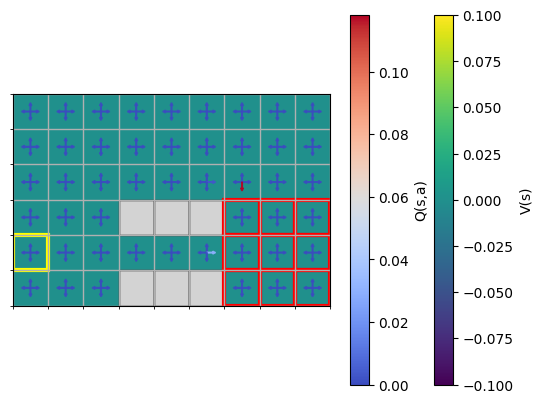

In [56]:
large_map = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 3, 3, 3],
    [0, 0, 0, 0, 0, 0, 3, 3, 3],
    [0, 0, 0, 1, 1, 1, 3, 3, 3]
]

large_init_state = 36
T_map, R_map = transition_probs_from_map(large_map, start_state=large_init_state)
vs_q_po, Q_po = Q_learning(T_map, R_map, 0.8, 100000, 0.01, 0.2, large_init_state)

plot_gridworld_with_q(large_map, Q_po, large_init_state)